# One Pipeline, Three Regions

The thesis of AI2Analytics is that pipeline *logic* is portable but *data* never
is. This notebook exercises that claim: one `SegmentationPipeline`, three
synthetic schemas (US weekly HCP, EU monthly account, BRIC quarterly account),
side-by-side comparison, plotted.

In [1]:
# Run once per session. In Colab, this installs into the runtime;
# in local Jupyter, it goes to the active kernel's environment.
import sys, subprocess
def _ensure(pkg, import_name=None):
    name = import_name or pkg.split('[')[0].split('==')[0]
    try:
        __import__(name)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

# In Colab/Jupyter, install ai2analytics from GitHub. If it's already
# installed locally (editable), this is a no-op.
try:
    import ai2analytics  # noqa: F401
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                           'git+https://github.com/jamesyoung93/AI2Analytics.git'])

# Plot helpers (matplotlib is already a hard dep of ai2analytics)
_ensure('matplotlib')
print('Setup complete.')

Setup complete.


## 1. Generate three regional datasets

In [2]:
from ai2analytics.datasets import us_hcp, eu_account, bric

us = us_hcp.generate_all(seed=42)
eu = eu_account.generate_all(seed=43)
br = bric.generate_all(seed=44)

print('US HCP reference :', us['hcp_reference'].shape, '|', list(us['hcp_reference'].columns)[:5], '...')
print('EU accounts      :', eu['account_reference'].shape, '|', list(eu['account_reference'].columns)[:5], '...')
print('BRIC accounts    :', br['account_master'].shape, '|', list(br['account_master'].columns)[:5], '...')

Generating synthetic US HCP data (seed=42) ...
  hcp_reference:        5,000 rows


  hcp_weekly:         114,011 rows


  calls:               32,726 rows
  team_a_alignment:     4,255 rows
  team_b_alignment:     3,964 rows
  portfolio_decile:     5,000 rows
  priority_targets:       500 rows
Done.

Generating synthetic EU account data (seed=43) ...
  account_reference:    3,000 rows


  account_monthly:     26,662 rows
  visits:              19,602 rows
  kam_alignment:        2,635 rows
  medical_alignment:    2,175 rows
Done.

Generating synthetic BRIC data (seed=44) ...
  account_master:             2,000 rows


  quarterly_performance:     11,440 rows
  engagement:                11,440 rows
  sales_alignment:            1,624 rows
Done.

US HCP reference : (5000, 5) | ['npi', 'WRITER_FLAG', 'TARGET_FLAG', 'IL_17_TRX_L12M', 'IL_23_TRX_L12M'] ...
EU accounts      : (3000, 6) | ['PRESCRIBER_ID', 'ACCOUNT_NAME', 'REGION', 'SEGMENT', 'TIER'] ...
BRIC accounts    : (2000, 6) | ['ACCOUNT_ID', 'COUNTRY_CODE', 'CITY', 'INSTITUTION_TYPE', 'CHANNEL'] ...


Three completely different schemas:

| Region | Entity ID | Features used |
|---|---|---|
| US | `npi` (10-digit int) | `IL_17_TRX_L12M`, `IL_23_TRX_L12M` |
| EU | `PRESCRIBER_ID` (`ACC-XXXXX`) | `UNITS_SOLD_L12M`, `TIER` |
| BRIC | `ACCOUNT_ID` (numeric) | join q-perf + master to get revenue & engagement |

Same pipeline class, different `SegmentationConfig`.

## 2. Run the same pipeline on all three

In [3]:
from ai2analytics.templates.segmentation import SegmentationConfig, SegmentationPipeline

# US: writers vs non-writers, two Rx features
us_out = SegmentationPipeline().run(
    SegmentationConfig(
        analysis_name='us_hcp',
        col_entity_id='npi',
        feature_columns=['IL_17_TRX_L12M', 'IL_23_TRX_L12M'],
        n_segments=4,
        method='kmeans',
        output_csv='seg_us.csv',
    ),
    dataframes={'entity_data': us['hcp_reference']},
)


  PIPELINE: us_hcp Segmentation

STAGE 1: Loading data
  Entity data:  5,000 rows (in-memory)
  Feature cols: 2 specified
  Done.

STAGE 2: Preparing features
  Missing handling: filled with column median
  Feature matrix:   5,000 entities x 2 features
  Normalization:    standard
  Done.

STAGE 3: Fitting segments
  Method: kmeans


  Segments:     4
  Silhouette:   0.6142
  Done.

STAGE 4: Building output
  Assignments:  5,000 entities
  Profiles:     4 segments x 2 features
  Done.

STAGE 5: Writing output
  CSV:   seg_us.csv (5,000 rows)
  Done.


PIPELINE COMPLETE
  Analysis:     us_hcp
  Entities:     5,000
  Segments:     4
  Method:       kmeans
  Silhouette:   0.6142
    Segment 0: 315 entities
    Segment 1: 3,419 entities
    Segment 2: 917 entities
    Segment 3: 349 entities
  Output CSV:   seg_us.csv


In [4]:
# EU: account volume + tier; let the pipeline pick KMeans vs hierarchical
eu_out = SegmentationPipeline().run(
    SegmentationConfig(
        analysis_name='eu_account',
        col_entity_id='PRESCRIBER_ID',
        feature_columns=['UNITS_SOLD_L12M', 'TIER'],
        n_segments=3,
        method='auto',
        output_csv='seg_eu.csv',
    ),
    dataframes={'entity_data': eu['account_reference']},
)


  PIPELINE: eu_account Segmentation

STAGE 1: Loading data
  Entity data:  3,000 rows (in-memory)
  Feature cols: 2 specified
  Done.

STAGE 2: Preparing features
  Missing handling: filled with column median
  Feature matrix:   3,000 entities x 2 features
  Normalization:    standard
  Done.

STAGE 3: Fitting segments
  Method: auto (trying both kmeans and hierarchical)


C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=12.
  warnings.warn(


  KMeans       (k=3): silhouette=0.5720
  Hierarchical (k=3): silhouette=0.5640
  Selected: kmeans
  Segments:     3
  Silhouette:   0.5720
  Done.

STAGE 4: Building output
  Assignments:  3,000 entities
  Profiles:     3 segments x 2 features
  Done.

STAGE 5: Writing output
  CSV:   seg_eu.csv (3,000 rows)
  Done.


PIPELINE COMPLETE
  Analysis:     eu_account
  Entities:     3,000
  Segments:     3
  Method:       kmeans
  Silhouette:   0.5720
    Segment 0: 1,786 entities
    Segment 1: 1,079 entities
    Segment 2: 135 entities
  Output CSV:   seg_eu.csv


In [5]:
# BRIC: build a richer per-account view by joining quarterly perf into master
import pandas as pd
qsum = (br['quarterly_performance']
        .groupby('ACCOUNT_ID', as_index=False)
        .agg(REVENUE_L12M=('REVENUE_LOCAL', 'sum'),
             AVG_COMPLIANCE=('COMPLIANCE_RATE', 'mean'),
             AVG_PATIENT_STARTS=('PATIENT_STARTS', 'mean')))
bric_view = br['account_master'].merge(qsum, on='ACCOUNT_ID', how='left').fillna(0)

br_out = SegmentationPipeline().run(
    SegmentationConfig(
        analysis_name='bric_account',
        col_entity_id='ACCOUNT_ID',
        feature_columns=['REVENUE_L12M', 'AVG_COMPLIANCE', 'AVG_PATIENT_STARTS'],
        n_segments=4,
        method='auto',
        normalize=True,
        output_csv='seg_bric.csv',
    ),
    dataframes={'entity_data': bric_view},
)


  PIPELINE: bric_account Segmentation

STAGE 1: Loading data
  Entity data:  2,000 rows (in-memory)
  Feature cols: 3 specified
  Done.

STAGE 2: Preparing features
  Missing handling: filled with column median
  Feature matrix:   2,000 entities x 3 features
  Normalization:    standard
  Done.

STAGE 3: Fitting segments
  Method: auto (trying both kmeans and hierarchical)


C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(


  KMeans       (k=4): silhouette=0.5163
  Hierarchical (k=4): silhouette=0.5173
  Selected: hierarchical
  Segments:     4
  Silhouette:   0.5173
  Done.

STAGE 4: Building output
  Assignments:  2,000 entities
  Profiles:     4 segments x 3 features
  Done.

STAGE 5: Writing output
  CSV:   seg_bric.csv (2,000 rows)
  Done.


PIPELINE COMPLETE
  Analysis:     bric_account
  Entities:     2,000
  Segments:     4
  Method:       hierarchical
  Silhouette:   0.5173
    Segment 0: 1,213 entities
    Segment 1: 534 entities
    Segment 2: 31 entities
    Segment 3: 222 entities
  Output CSV:   seg_bric.csv


## 3. Side-by-side comparison

In [6]:
import pandas as pd

def summarise(name, out):
    s = out.summary_stats
    return {
        'region': name,
        'entities': s['n_entities'],
        'features': len(out.profiles.columns) - 1,
        'method': s['method'],
        'segments': s['n_segments'],
        'silhouette': round(s['silhouette_score'], 4),
    }

pd.DataFrame([summarise('US', us_out), summarise('EU', eu_out), summarise('BRIC', br_out)])

,region,entities,features,method,segments,silhouette
0,US,5000,2,kmeans,4,0.6142
1,EU,3000,2,kmeans,3,0.5720
2,BRIC,2000,3,hierarchical,4,0.5173


## 4. Plot segment sizes by region

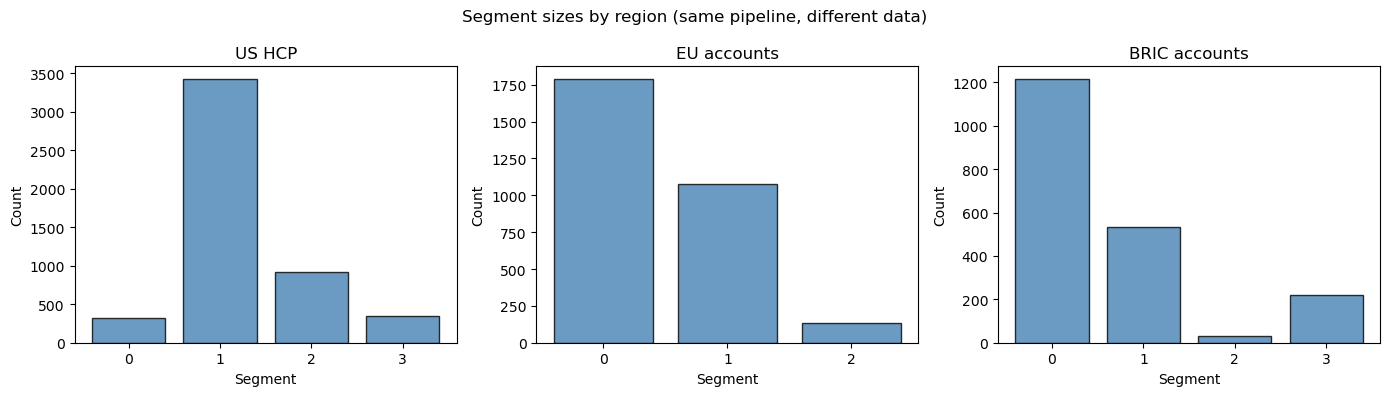

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, out) in zip(axes, [('US HCP', us_out), ('EU accounts', eu_out), ('BRIC accounts', br_out)]):
    sizes = out.summary_stats['segment_sizes']
    ax.bar([str(k) for k in sorted(sizes)], [sizes[k] for k in sorted(sizes)],
           color='steelblue', edgecolor='black', alpha=0.8)
    ax.set_title(name)
    ax.set_xlabel('Segment')
    ax.set_ylabel('Count')
plt.suptitle('Segment sizes by region (same pipeline, different data)')
plt.tight_layout()
plt.show()

## 5. Profile heatmaps (what each segment looks like)

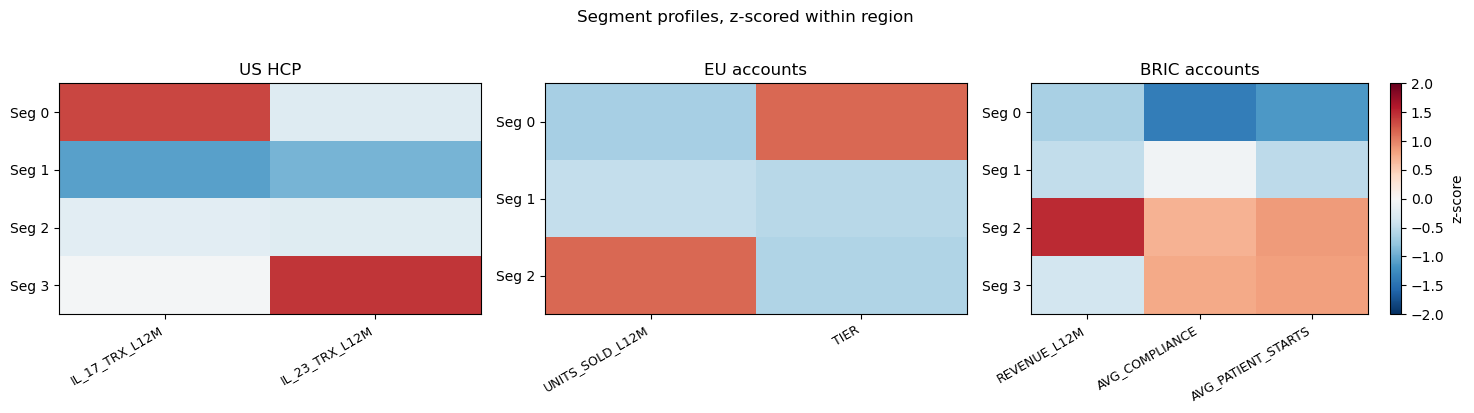

In [8]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, out) in zip(axes, [('US HCP', us_out), ('EU accounts', eu_out), ('BRIC accounts', br_out)]):
    p = out.profiles.set_index('SEGMENT')
    # Standardise columns within region for visual comparability
    pn = (p - p.mean()) / (p.std() + 1e-9)
    im = ax.imshow(pn.values, aspect='auto', cmap='RdBu_r', vmin=-2, vmax=2)
    ax.set_xticks(range(len(pn.columns)))
    ax.set_xticklabels(pn.columns, rotation=30, ha='right', fontsize=9)
    ax.set_yticks(range(len(pn.index)))
    ax.set_yticklabels([f'Seg {i}' for i in pn.index])
    ax.set_title(name)
plt.colorbar(im, ax=axes[-1], label='z-score')
plt.suptitle('Segment profiles, z-scored within region', y=1.02)
plt.tight_layout()
plt.show()

## What this shows

- The **identical** `SegmentationPipeline` class produced sensible clusters for
  three completely different schemas.
- All schema differences live in `SegmentationConfig` (entity ID column, feature
  columns, optional method='auto').
- Silhouette is in a healthy 0.4–0.7 range across all three despite the noisy
  synthetic data.

The same trick scales to dozens of brands or regions: write the pipeline once,
configure many times.